<a href="https://colab.research.google.com/github/Infraking/Financial-Fraud-Detection-System/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection Dataset - Exploratory Data Analysis (EDA)

## Objective
The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Fraud Detection dataset. The analysis aims to understand the dataset structure, identify missing values, examine fraud distribution, analyze transaction types, and discover useful insights before building a machine learning model.

## 1. Import Required Libraries

This section imports the libraries required for data loading, manipulation, visualization, and analysis.

## 2. Load the Dataset

The dataset is loaded into a pandas DataFrame for further analysis.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/PS_20174392719_1491204439457_log.csv.zip", compression='zip')

## 3. Dataset Dimensions

The shape of the dataset is checked to determine the number of rows and columns.

In [ ]:
df.shape

(6362620, 11)

## 4. Display First Five Records

The first five rows are displayed to understand the dataset structure and sample values.

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 5. View Dataset Columns

This section displays the names of all features available in the dataset.

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## 6. Missing Value Analysis

The dataset is checked for missing values to ensure data quality before further analysis.

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


## 7. Fraud Distribution

This section counts the number of fraudulent and genuine transactions to understand the class distribution.

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


## 8. Import Visualization Libraries

Matplotlib and Seaborn are imported for creating visualizations.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## 9. Visualization of Fraud Distribution

A count plot is generated to compare the number of genuine and fraudulent transactions.

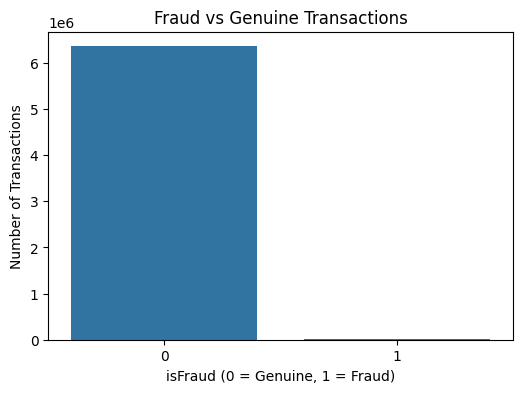

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("isFraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

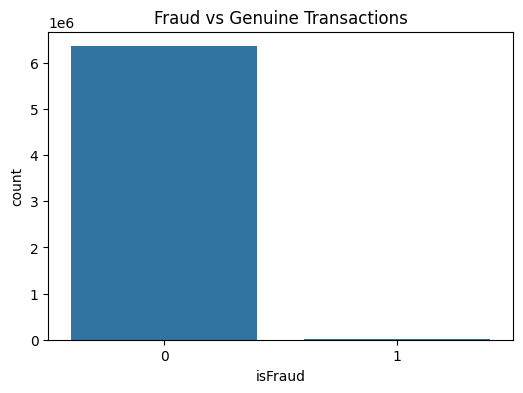

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.savefig("fraud_distribution.png")
plt.show()

## 10. Fraud Analysis by Transaction Type

This section calculates the number of fraudulent transactions for each transaction type.

In [ ]:
df.groupby('type')['isFraud'].sum()

,isFraud
type,
CASH_IN,0
CASH_OUT,4116
DEBIT,0
PAYMENT,0
TRANSFER,4097


## 11. Visualization of Fraud by Transaction Type

A count plot is generated to compare fraudulent and genuine transactions across different transaction types.

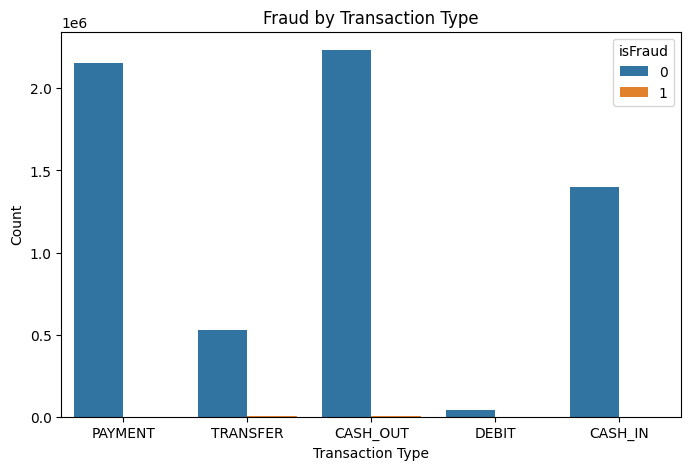

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='type', hue='isFraud', data=df)

plt.title("Fraud by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

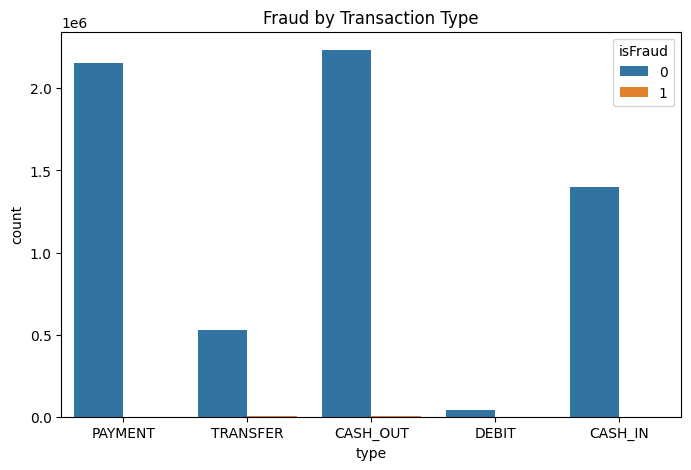

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='type', hue='isFraud', data=df)

plt.title("Fraud by Transaction Type")

plt.savefig("fraud_by_type.png")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include='number')

## 12. Correlation Analysis

A correlation heatmap is generated to understand the relationships among numerical features.

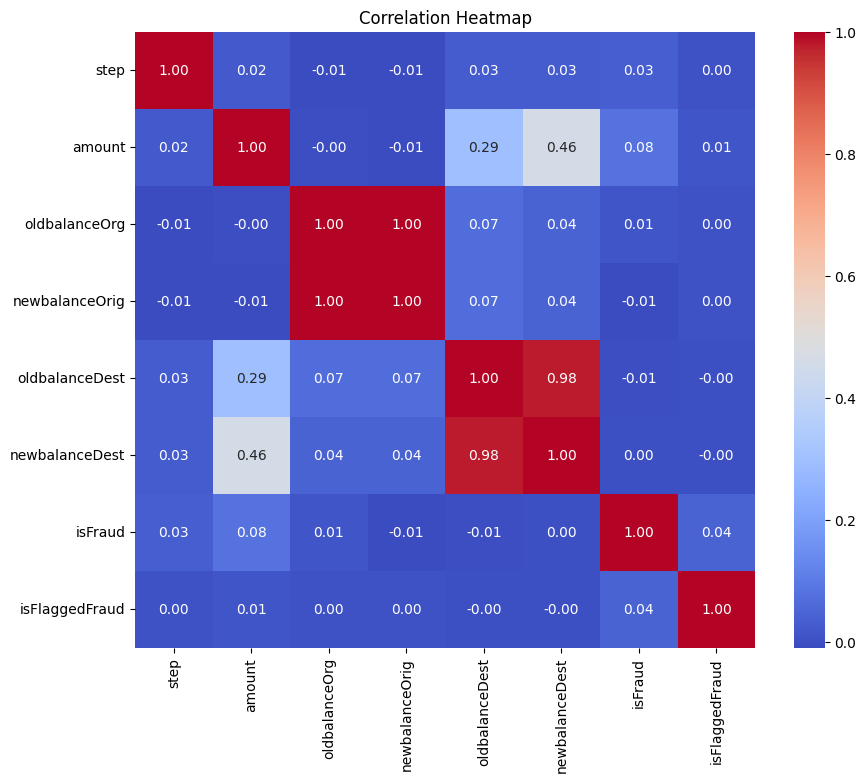

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

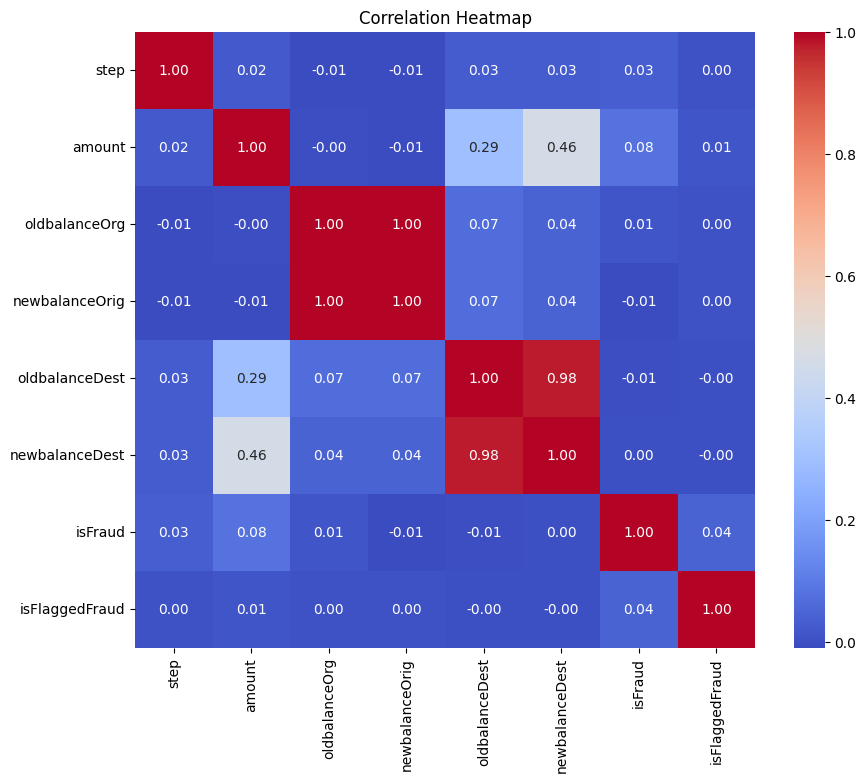

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

# Conclusion

The exploratory data analysis reveals that the dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of the total transactions. Fraud mainly occurs in CASH_OUT and TRANSFER transaction types, while other transaction types show almost no fraudulent activity. No missing values were found in the dataset, indicating good data quality. The insights obtained from this analysis will help in selecting appropriate preprocessing techniques and machine learning algorithms for fraud detection.